# Модель ранжирования контрагентов: обучение и анализ

Двухэтапная схема:

1. **Кандидаты.** Для каждого лота три канала по истории: коды ОКПД2, прошлые исполнители у заказчика, текстовое сходство с прошлыми лотами поставщика. Каналы объединяются через reciprocal rank fusion, остаётся до 300 кандидатов.
2. **Ранжирование.** LightGBM LambdaRank на 33 предметных признаках пары «лот × кандидат». У признаков-счётчиков задана монотонность: больше побед по коду или у заказчика никогда не снижает оценку.

**Без утечки из будущего:** профили поставщиков для лота месяца M считаются по истории строго до начала месяца M.

| Окно | Месяцы | Роль |
|---|---|---|
| train | 2025-04 – 2025-08 | обучение (отрицательные примеры сэмплируются) |
| valid | 2025-09 | ранняя остановка и калибровка вероятностей |
| test | 2025-10 – 2025-12 | итоговая оценка, все кандидаты |

**Интерпретируемость на проде:** вклад каждого признака (SHAP, `pred_contrib`) переводится в причины на русском языке, статус контрагента присваивается прозрачным правилом. Код пакета `recsys/` общий для обучения и сервиса.

In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import lightgbm as lgb

from recsys.data import Dataset, month_label
from recsys.text import TextModel
from recsys.profiles import Snapshot
from recsys import candidates as C
from recsys.features import FEATURES, MONOTONE, GROUP, TITLE, build_features
from recsys.metrics import evaluate, winner_ranks
from recsys.explain import explain
from recsys.inference import softmax_by_lot

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 160)

FEAT_DIR = Path('data/features'); FEAT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path('models'); MODEL_DIR.mkdir(exist_ok=True)
TRAIN_MONTHS, VALID_MONTH, TEST_MONTHS = [15, 16, 17, 18, 19], 20, [21, 22, 23]
HARD_NEG, RAND_NEG, VALID_LOTS, SEED = 60, 30, 10_000, 42
RANK_COLS = ['rank_code', 'rank_cust', 'rank_text', 'cand_rank']

C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, INK2, GRID, SURF = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
mpl.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF, 'figure.dpi': 110, 'font.size': 10,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.titlecolor': INK, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.major.size': 0, 'ytick.major.size': 0,
    'legend.frameon': False, 'legend.labelcolor': INK, 'lines.linewidth': 2,
})
pct = lambda x: f'{100 * x:.1f}%'
fmt = lambda x: f'{x:,.0f}'.replace(',', ' ')

## 1. Данные и текстовые векторы

Текстовая модель (TF-IDF по леммам → SVD 256) обучается без меток, только на текстах, поэтому её можно строить на всех лотах.

In [2]:
t0 = time.time()
ds = Dataset('data/processed')
print(f'Данные: {fmt(len(ds.lots))} лотов, {fmt(len(ds.events))} участий, {fmt(len(ds.vocab.supplier_inn))} поставщиков, {time.time() - t0:.0f} с')

vec_path, tm_path = FEAT_DIR / 'lot_vecs.npy', MODEL_DIR / 'text_model.joblib'
if vec_path.exists() and tm_path.exists():
    lot_vecs = np.load(vec_path)
else:
    tm = TextModel()
    lot_vecs = tm.fit_transform(ds.lot_docs())
    tm.save(tm_path); np.save(vec_path, lot_vecs)
print('Векторы лотов:', lot_vecs.shape)

Данные: 604 452 лотов, 1 009 976 участий, 44 174 поставщиков, 13 с
Векторы лотов: (604452, 256)


## 2. Кандидаты и признаки по месяцам

Для каждого месяца M: срез профилей на M → кандидаты → признаки → метки. Для обучения сохраняются все положительные пары, 60 самых трудных и 30 случайных отрицательных на лот; для valid и test — все кандидаты. Готовые файлы кешируются в `data/features/`.

In [3]:
def step(msg, t0):
    print(f'    {msg}: {time.time() - t0:.0f} с', flush=True)

def month_frame(M):
    t0 = time.time()
    snap = Snapshot.build(ds, M, lot_vecs)
    lots = ds.lots[(ds.lots.month == M) & ds.lots.train_eligible].lot_id.values
    b = ds.batch(lots, lot_vecs)
    step(f'срез профилей ({fmt(len(lots))} лотов)', t0); t0 = time.time()
    cands = C.generate(snap, b)
    step(f'кандидаты ({fmt(len(cands))} пар)', t0); t0 = time.time()
    F = build_features(snap, b, cands)
    step('признаки', t0)
    F = F.merge(cands[['lot_id', 'sid'] + RANK_COLS], on=['lot_id', 'sid'], how='left')
    truth = ds.labels(lots)
    F = F.merge(truth, on=['lot_id', 'sid'], how='left')
    F['label'] = F.label.fillna(0).astype('int8')
    return F.sort_values(['lot_id', 'cand_rank']).reset_index(drop=True), truth

def sample_train(F):
    pos_lots = F.loc[F.label > 0, 'lot_id'].unique()
    F = F[F.lot_id.isin(pos_lots)]
    pos = F[F.label > 0]
    neg = F[F.label == 0].copy()
    neg['nr'] = neg.groupby('lot_id').cumcount()
    hard = neg[neg.nr < HARD_NEG]
    rnd = neg[neg.nr >= HARD_NEG].sample(frac=1, random_state=SEED).groupby('lot_id').head(RAND_NEG)
    return pd.concat([pos, hard.drop(columns='nr'), rnd.drop(columns='nr')]).sort_values(['lot_id', 'cand_rank']).reset_index(drop=True)

cand_stats = []
ALL_MONTHS = TRAIN_MONTHS + [VALID_MONTH] + TEST_MONTHS
for i, M in enumerate(ALL_MONTHS, 1):
    path = FEAT_DIR / f'm{M}.parquet'
    stat_path = FEAT_DIR / f'm{M}_stats.json'
    if path.exists() and stat_path.exists():
        cand_stats.append(json.loads(stat_path.read_text()))
        print(f'[{i}/{len(ALL_MONTHS)}] {month_label(M)}: взято из кеша', flush=True)
        continue
    print(f'[{i}/{len(ALL_MONTHS)}] {month_label(M)}', flush=True)
    t0 = time.time()
    F, truth = month_frame(M)
    win = truth[truth.label == 2].merge(ds.lots[['lot_id', 'platform']], on='lot_id')
    st = {'month': month_label(M), 'M': M, 'lots': int(win.lot_id.nunique()), 'pairs': int(len(F))}
    for col in RANK_COLS:
        r = win.merge(F[['lot_id', 'sid', col]], on=['lot_id', 'sid'], how='left')
        for plat in ['EM', 'AISGZ']:
            rr = r[r.platform == plat].groupby('lot_id')[col].min()
            st[f'{col}|{plat}'] = float(rr.notna().mean())
        st[f'{col}|all'] = float(r.groupby('lot_id')[col].min().notna().mean())
    if M in TRAIN_MONTHS:
        F = sample_train(F)
    elif M == VALID_MONTH:
        lots_pos = F.loc[F.label > 0, 'lot_id'].unique()
        keep = np.random.default_rng(SEED).choice(lots_pos, size=min(VALID_LOTS, len(lots_pos)), replace=False)
        F[F.lot_id.isin(keep)].to_parquet(FEAT_DIR / f'm{M}_es.parquet', compression='zstd')
    F.to_parquet(path, compression='zstd')
    stat_path.write_text(json.dumps(st))
    cand_stats.append(st)
    print(f"    готово: {fmt(len(F))} строк сохранено, победитель среди кандидатов в {pct(st['cand_rank|all'])} лотов, всего {time.time() - t0:.0f} с", flush=True)

cand_stats = pd.DataFrame(cand_stats).set_index('month')

[1/9] 2025-04
    срез профилей (26 928 лотов): 3 с
    кандидаты (7 947 957 пар): 53 с
    признаки: 110 с
    готово: 2 154 462 строк сохранено, победитель среди кандидатов в 84.7% лотов, всего 205 с
[2/9] 2025-05
    срез профилей (20 724 лотов): 4 с
    кандидаты (6 117 200 пар): 43 с
    признаки: 76 с
    готово: 1 618 248 строк сохранено, победитель среди кандидатов в 82.9% лотов, всего 148 с
[3/9] 2025-06
    срез профилей (19 437 лотов): 3 с
    кандидаты (5 751 324 пар): 36 с
    признаки: 63 с
    готово: 1 503 491 строк сохранено, победитель среди кандидатов в 82.1% лотов, всего 124 с
[4/9] 2025-07
    срез профилей (16 934 лотов): 3 с
    кандидаты (5 011 706 пар): 31 с
    признаки: 54 с
    готово: 1 337 440 строк сохранено, победитель среди кандидатов в 82.7% лотов, всего 107 с
[5/9] 2025-08
    срез профилей (16 015 лотов): 3 с
    кандидаты (4 739 616 пар): 29 с
    признаки: 52 с
    готово: 1 286 737 строк сохранено, победитель среди кандидатов в 83.8% лотов, всего 

,по ОКПД2 (200),по заказчику (100),по тексту (100),объединение (300),"объединение, ЭМ","объединение, АИС ГЗ"
month,,,,,,
2025-04,74.8%,49.4%,51.9%,84.7%,89.3%,80.6%
2025-05,71.6%,50.3%,48.8%,82.9%,89.2%,77.3%
2025-06,69.2%,50.7%,47.1%,82.1%,88.7%,76.6%
2025-07,71.2%,49.6%,47.1%,82.7%,86.8%,78.8%
2025-08,71.6%,51.1%,46.9%,83.8%,87.2%,80.3%
2025-09,68.9%,51.7%,45.0%,82.5%,87.9%,76.9%
2025-10,73.3%,55.0%,48.7%,85.4%,89.6%,81.2%
2025-11,77.1%,58.6%,52.5%,87.7%,90.2%,85.2%
2025-12,80.8%,64.7%,57.5%,90.8%,92.6%,88.3%


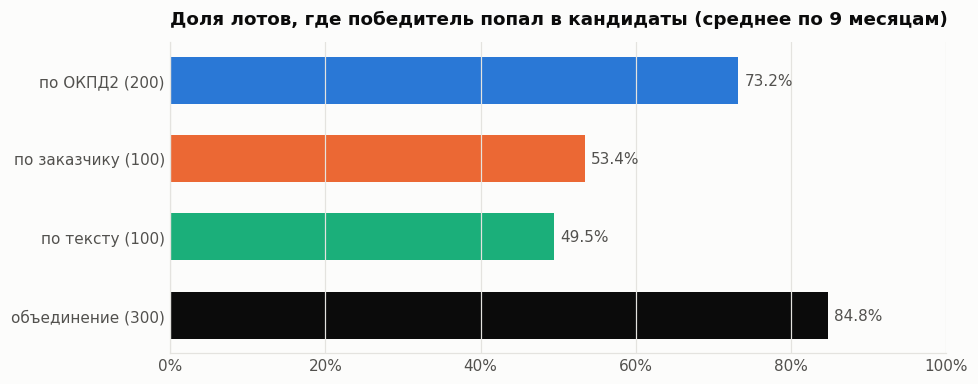

In [4]:
cs = pd.DataFrame({
    'по ОКПД2 (200)': cand_stats['rank_code|all'], 'по заказчику (100)': cand_stats['rank_cust|all'],
    'по тексту (100)': cand_stats['rank_text|all'], 'объединение (300)': cand_stats['cand_rank|all'],
    'объединение, ЭМ': cand_stats['cand_rank|EM'], 'объединение, АИС ГЗ': cand_stats['cand_rank|AISGZ'],
})
display(cs.map(pct))

fig, ax = plt.subplots(figsize=(9, 3.6))
cols = ['по ОКПД2 (200)', 'по заказчику (100)', 'по тексту (100)', 'объединение (300)']
colors = [C_BLUE, C_ORANGE, C_AQUA, INK]
avg = cs[cols].mean()
ax.barh(cols[::-1], avg[::-1], color=colors[::-1], height=0.6)
for i, v in enumerate(avg[::-1]):
    ax.annotate(pct(v), (v, i), xytext=(4, 0), textcoords='offset points', va='center', color=INK2)
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0)); ax.grid(axis='y', visible=False)
ax.set_title('Доля лотов, где победитель попал в кандидаты (среднее по 9 месяцам)')
plt.tight_layout(); plt.show()

## 3. Обучение LightGBM LambdaRank

- Метки: 2 — победитель, 1 — участник (есть только в ЭМ), 0 — кандидат, который не участвовал. `label_gain = [0, 1, 3]`.
- Монотонные ограничения на счётчики побед по ОКПД2, у заказчика и в районе, на покрытие кодов, долю в группе и текстовое сходство.
- Ранняя остановка по NDCG@10 на 10 000 лотах сентября.

In [5]:
def to_lgb(F, ref=None):
    F = F.sort_values(['lot_id', 'cand_rank'])
    group = F.groupby('lot_id', sort=False).size().values
    return lgb.Dataset(F[FEATURES], label=F.label, group=group, feature_name=FEATURES, reference=ref, free_raw_data=False)

train_df = pd.concat([pd.read_parquet(FEAT_DIR / f'm{M}.parquet') for M in TRAIN_MONTHS], ignore_index=True)
es_df = pd.read_parquet(FEAT_DIR / f'm{VALID_MONTH}_es.parquet')
print(f'train: {fmt(train_df.lot_id.nunique())} лотов, {fmt(len(train_df))} строк | valid: {fmt(es_df.lot_id.nunique())} лотов, {fmt(len(es_df))} строк')
print('Метки train:', train_df.label.value_counts().sort_index().to_dict())

dtrain = to_lgb(train_df)
dvalid = to_lgb(es_df, ref=dtrain)
PARAMS = dict(
    objective='lambdarank', metric='ndcg', eval_at=[10, 1, 5], label_gain=[0, 1, 3],
    lambdarank_truncation_level=30, learning_rate=0.05, num_leaves=63, min_data_in_leaf=200,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
    monotone_constraints=MONOTONE, monotone_constraints_method='intermediate',
    num_threads=8, seed=SEED, verbosity=-1,
)
evals = {}
t0 = time.time()
booster = lgb.train(PARAMS, dtrain, num_boost_round=3000, valid_sets=[dvalid], valid_names=['valid'],
                    callbacks=[lgb.early_stopping(100, first_metric_only=True, verbose=False),
                               lgb.record_evaluation(evals), lgb.log_evaluation(25)])
BEST = booster.best_iteration
print(f'Лучшая итерация: {BEST}, NDCG@10 valid = {evals["valid"]["ndcg@10"][BEST - 1]:.4f}, {time.time() - t0:.0f} с')

train: 86 103 лотов, 7 900 378 строк | valid: 10 000 лотов, 2 959 900 строк
Метки train: {0: 7749270, 1: 67712, 2: 83396}
[25]	valid's ndcg@1: 0.330767	valid's ndcg@5: 0.447112	valid's ndcg@10: 0.485103
[50]	valid's ndcg@1: 0.3423	valid's ndcg@5: 0.459311	valid's ndcg@10: 0.500256
[75]	valid's ndcg@1: 0.352733	valid's ndcg@5: 0.470201	valid's ndcg@10: 0.511514
[100]	valid's ndcg@1: 0.357067	valid's ndcg@5: 0.475965	valid's ndcg@10: 0.518597
[125]	valid's ndcg@1: 0.359133	valid's ndcg@5: 0.479853	valid's ndcg@10: 0.522572
[150]	valid's ndcg@1: 0.361633	valid's ndcg@5: 0.483811	valid's ndcg@10: 0.525726
[175]	valid's ndcg@1: 0.362433	valid's ndcg@5: 0.485248	valid's ndcg@10: 0.527537
[200]	valid's ndcg@1: 0.3621	valid's ndcg@5: 0.486861	valid's ndcg@10: 0.528813
[225]	valid's ndcg@1: 0.3643	valid's ndcg@5: 0.489547	valid's ndcg@10: 0.531033
[250]	valid's ndcg@1: 0.365233	valid's ndcg@5: 0.490514	valid's ndcg@10: 0.532072
[275]	valid's ndcg@1: 0.3664	valid's ndcg@5: 0.491872	valid's ndcg@

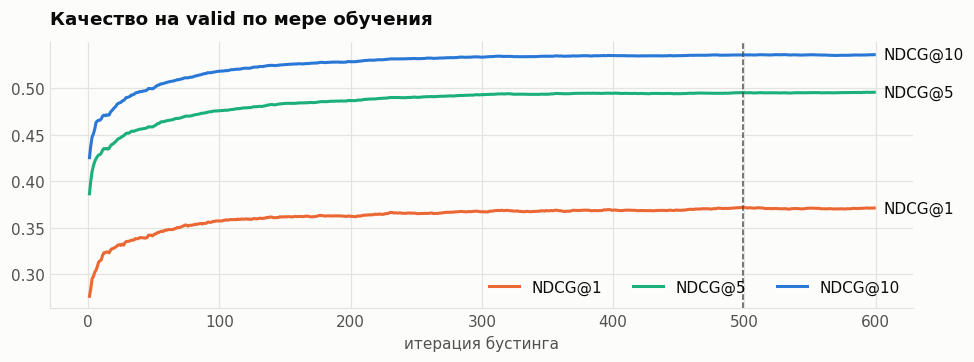

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for k, col in [('ndcg@1', C_ORANGE), ('ndcg@5', C_AQUA), ('ndcg@10', C_BLUE)]:
    y = evals['valid'][k]
    ax.plot(range(1, len(y) + 1), y, color=col, label=k.upper())
    ax.annotate(k.upper(), (len(y), y[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=INK)
ax.axvline(BEST, color=INK2, lw=1, ls='--')
ax.set_title('Качество на valid по мере обучения'); ax.set_xlabel('итерация бустинга'); ax.legend(loc='lower right', ncol=3)
plt.tight_layout(); plt.show()

### Калибровка вероятности

Скор LambdaRank — относительная величина внутри лота. Для интерфейса переводим его в вероятность победы: softmax по кандидатам лота с температурой, подобранной на valid, умноженный на долю лотов, где победитель вообще попал в кандидаты.

In [7]:
valid_full = pd.read_parquet(FEAT_DIR / f'm{VALID_MONTH}.parquet')
valid_full['score'] = booster.predict(valid_full[FEATURES], num_iteration=BEST)
vw = valid_full[valid_full.lot_id.isin(valid_full.loc[valid_full.label == 2, 'lot_id'])]

def nll(T):
    p = softmax_by_lot(vw.lot_id.values, vw.score.values, T)
    return -np.log(np.clip(p[vw.label.values == 2], 1e-12, None)).mean()

grid = np.exp(np.linspace(np.log(0.1), np.log(10), 61))
losses = [nll(T) for T in grid]
TEMP = float(grid[int(np.argmin(losses))])
COVERAGE = float(cand_stats.loc[month_label(VALID_MONTH), 'cand_rank|all'])
del train_df, es_df, dtrain, dvalid, valid_full, vw
print(f'Температура: {TEMP:.3f}; доля лотов с победителем среди кандидатов (valid): {pct(COVERAGE)}')

Температура: 0.794; доля лотов с победителем среди кандидатов (valid): 82.5%


## 4. Оценка на test (октябрь–декабрь 2025)

Метрики считаются по **всем** лотам теста с победителем. Если победителя нет среди кандидатов, лот считается промахом.

Бейзлайны:
- **Популярные по ОКПД2** — канал кодов, сортировка по числу побед с кодами лота;
- **История заказчика → ОКПД2** — сначала прошлые исполнители у заказчика, затем канал кодов;
- **Объединение каналов (RRF)** — итоговый порядок генератора кандидатов без модели.

In [8]:
test_parts, truth_parts = [], []
for M in TEST_MONTHS:
    F = pd.read_parquet(FEAT_DIR / f'm{M}.parquet')
    F[RANK_COLS] = F[RANK_COLS].astype('float32')
    F['score'] = booster.predict(F[FEATURES], num_iteration=BEST)
    F['p_win'] = softmax_by_lot(F.lot_id.values, F.score.values, TEMP) * COVERAGE
    test_parts.append(F)
    lots = ds.lots[(ds.lots.month == M) & ds.lots.train_eligible].lot_id.values
    truth_parts.append(ds.labels(lots))
test = pd.concat(test_parts, ignore_index=True); del test_parts
truth = pd.concat(truth_parts, ignore_index=True)

BIG = 1e6
test['b_code'] = -test.rank_code.fillna(BIG)
test['b_cust'] = np.where(test.rank_cust.notna(), BIG - test.rank_cust, -test.rank_code.fillna(BIG))
test['b_rrf'] = -test.cand_rank
slim = test[['lot_id', 'sid', 'score', 'b_code', 'b_cust', 'b_rrf']]
METHODS = {'Популярные по ОКПД2': 'b_code', 'История заказчика → ОКПД2': 'b_cust',
           'Объединение каналов (RRF)': 'b_rrf', 'Модель LightGBM': 'score'}
plat = ds.lots.set_index('lot_id').platform

rows = []
for seg, lots in [('Все', truth.lot_id.unique()), ('ЭМ', truth.lot_id[truth.lot_id.map(plat) == 'EM'].unique()),
                  ('АИС ГЗ', truth.lot_id[truth.lot_id.map(plat) == 'AISGZ'].unique())]:
    tt, ss = truth[truth.lot_id.isin(lots)], slim[slim.lot_id.isin(lots)]
    for name, col in METHODS.items():
        rows.append({'сегмент': seg, 'метод': name, **evaluate(ss, tt, col)})
res = pd.DataFrame(rows).set_index(['сегмент', 'метод'])
show = res.copy()
for c in show.columns:
    if c != 'лотов':
        show[c] = show[c].map(lambda v: f'{v:.3f}')
show

Recall@1 Recall@5 Recall@10 Recall@20 Recall@50 Recall@100    MRR NDCG@10  лотов
сегмент метод                                                                                                     
Все     Популярные по ОКПД2          0.109    0.295     0.388     0.496     0.630      0.720  0.204   0.252  88150
        История заказчика → ОКПД2    0.151    0.329     0.419     0.490     0.562      0.621  0.237   0.257  88150
        Объединение каналов (RRF)    0.308    0.518     0.603     0.679     0.767      0.818  0.407   0.444  88150
        Модель LightGBM              0.377    0.608     0.693     0.763     0.833      0.867  0.484   0.536  88150
ЭМ      Популярные по ОКПД2          0.128    0.342     0.439     0.546     0.677      0.764  0.234   0.300  47977
        История заказчика → ОКПД2    0.168    0.361     0.450     0.517     0.583      0.647  0.259   0.268  47977
        Объединение каналов (RRF)    0.336    0.557     0.636     0.709     0.799      0.849  0.439   0.474  47977
        Модель LightGBM              0.409    0.637     0.718     0.790     0.861      0.895  0.516   0.573  47977
АИС ГЗ  Популярные по ОКПД2          0.087    0.240     0.328     0.437     0.574      0.668  0.167   0.194  40173
        История заказчика → ОКПД2    0.130    0.291     0.383     0.459     0.536      0.591  0.210   0.243  40173
        Объединение каналов (RRF)    0.274    0.473     0.564     0.643     0.729      0.780  0.369   0.408  40173
        Модель LightGBM              0.338    0.574     0.663     0.731     0.801      0.834  0.446   0.492  40173

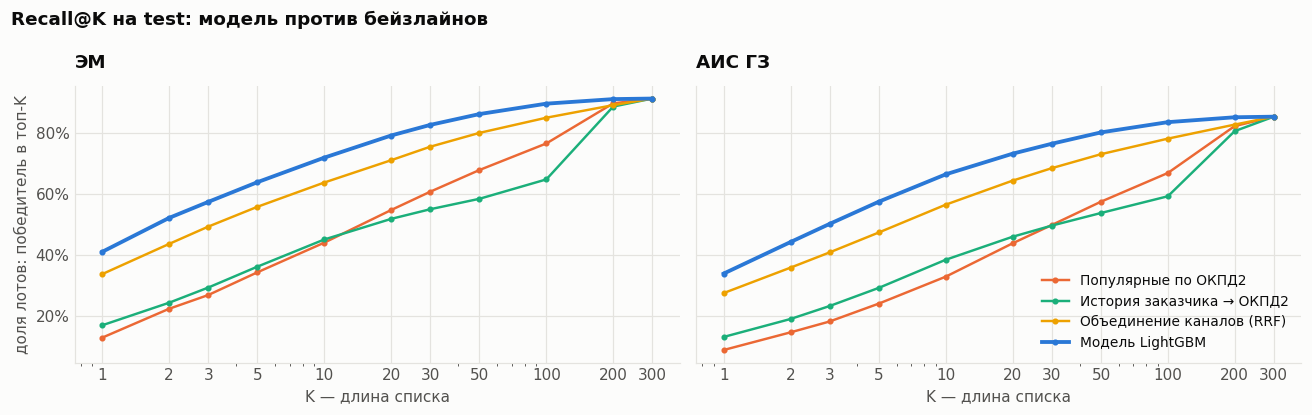

In [9]:
ks = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 300]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
mcol = {'Популярные по ОКПД2': C_ORANGE, 'История заказчика → ОКПД2': C_AQUA, 'Объединение каналов (RRF)': C_YELLOW, 'Модель LightGBM': C_BLUE}
for ax, (seg, p) in zip(axes, [('ЭМ', 'EM'), ('АИС ГЗ', 'AISGZ')]):
    lots = truth.lot_id[truth.lot_id.map(plat) == p].unique()
    tt, ss = truth[truth.lot_id.isin(lots)], slim[slim.lot_id.isin(lots)]
    for name, col in METHODS.items():
        r = winner_ranks(ss, tt, col)
        y = [(r <= k).mean() for k in ks]
        ax.plot(ks, y, color=mcol[name], label=name, lw=2.5 if col == 'score' else 1.6, marker='o', ms=3)
    ax.set_xscale('log'); ax.set_xticks(ks); ax.set_xticklabels(ks); ax.set_title(seg)
    ax.set_xlabel('K — длина списка'); ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[0].set_ylabel('доля лотов: победитель в топ-K')
axes[1].legend(loc='lower right', fontsize=9)
fig.suptitle('Recall@K на test: модель против бейзлайнов', x=0.01, ha='left', fontweight='bold', color=INK)
plt.tight_layout(); plt.show()

### 4.1 Где модель сильна и где слаба

Сегменты по истории победителя на момент лота: побеждал ли он раньше у этого заказчика, в этом классе ОКПД2, участвовал ли вообще.

In [10]:
ev = ds.events
lot_info = ds.lots.set_index('lot_id')[['month', 'cid', 'mc', 'platform', 'n_positions']]
w = truth[truth.label == 2][['lot_id', 'sid']].drop_duplicates('lot_id').join(lot_info, on='lot_id')
fw_cust = ev[ev.win == 1].groupby(['sid', 'cid']).month.min().rename('fw_cust')
fw_cls = ev[ev.win == 1].groupby(['sid', 'mc']).month.min().rename('fw_cls')
fp_any = ev.groupby('sid').month.min().rename('fp_any')
w = w.join(fw_cust, on=['sid', 'cid']).join(fw_cls, on=['sid', 'mc']).join(fp_any, on='sid')
w['segment'] = np.select(
    [w.fw_cust < w.month, w.fw_cls < w.month, w.fp_any < w.month],
    ['1. Побеждал у этого заказчика', '2. Побеждал в классе, новый для заказчика', '3. Участвовал, но не побеждал в классе'],
    '4. Нет истории до лота')
w['size'] = pd.cut(w.n_positions, [0, 1, 10, np.inf], labels=['1 позиция', '2–10 позиций', '> 10 позиций'])
r_model = winner_ranks(slim, truth, 'score').rename('r_model')
r_cust = winner_ranks(slim, truth, 'b_cust').rename('r_base')
w = w.join(r_model, on='lot_id').join(r_cust, on='lot_id')

def seg_table(by):
    g = w.groupby(by, observed=True)
    return pd.DataFrame({
        'лотов': g.size(), 'доля лотов': g.size() / len(w),
        'в кандидатах': g.r_model.apply(lambda r: np.isfinite(r).mean()),
        'Recall@10 модель': g.r_model.apply(lambda r: (r <= 10).mean()),
        'Recall@10 бейзлайн заказчика': g.r_base.apply(lambda r: (r <= 10).mean()),
        'Recall@1 модель': g.r_model.apply(lambda r: (r <= 1).mean()),
    })

def show_pct(t):
    t = t.copy()
    for c in t.columns:
        t[c] = t[c].map(fmt) if c == 'лотов' else t[c].map(pct)
    return t

display(show_pct(seg_table('segment')))
display(show_pct(seg_table(['platform', 'segment'])))
display(show_pct(seg_table('size')))

,лотов,доля лотов,в кандидатах,Recall@10 модель,Recall@10 бейзлайн заказчика,Recall@1 модель
segment,,,,,,
1. Побеждал у этого заказчика,54 665,62.0%,98.4%,85.3%,67.6%,54.6%
"2. Побеждал в классе, новый для заказчика",27 686,31.4%,85.1%,51.9%,0.1%,12.2%
"3. Участвовал, но не побеждал в классе",2 561,2.9%,23.8%,4.4%,0.0%,0.4%
4. Нет истории до лота,3 238,3.7%,0.0%,0.0%,0.0%,0.0%


лотов доля лотов в кандидатах Recall@10 модель Recall@10 бейзлайн заказчика Recall@1 модель
platform segment                                                                                                                                
AISGZ    1. Побеждал у этого заказчика              24 640      28.0%        97.6%            83.8%                        62.4%           49.8%
         2. Побеждал в классе, новый для заказчика  11 986      13.6%        82.9%            49.8%                         0.1%           10.9%
         3. Участвовал, но не побеждал в классе      1 137       1.3%        22.1%             2.1%                         0.1%            0.3%
         4. Нет истории до лота                      2 410       2.7%         0.0%             0.0%                         0.0%            0.0%
EM       1. Побеждал у этого заказчика              30 025      34.1%        99.1%            86.4%                        71.8%           58.5%
         2. Побеждал в классе, новый для заказчика  15 700      17.8%        86.8%            53.5%                         0.1%           13.1%
         3. Участвовал, но не побеждал в классе      1 424       1.6%        25.2%             6.2%                         0.0%            0.5%
         4. Нет истории до лота                        828       0.9%         0.0%             0.0%                         0.0%            0.0%

,лотов,доля лотов,в кандидатах,Recall@10 модель,Recall@10 бейзлайн заказчика,Recall@1 модель
size,,,,,,
1 позиция,45 506,51.6%,86.4%,66.6%,41.4%,36.6%
2–10 позиций,34 045,38.6%,90.0%,71.5%,42.4%,38.9%
> 10 позиций,8 599,9.8%,93.4%,74.7%,42.7%,38.6%


In [11]:
cls_names = pd.read_parquet('data/processed/okpd2_classes.parquet').set_index('okpd_l1').name
w['class'] = w.mc.map(lambda i: ds.vocab.okpd_class[i] if i >= 0 else None)
top_cls = w['class'].value_counts().head(10).index
t = seg_table(w['class'].where(w['class'].isin(top_cls)))
t.index = [f'{c} · {cls_names.get(c, "")}' for c in t.index]
show_pct(t.sort_values('лотов', ascending=False))

,лотов,доля лотов,в кандидатах,Recall@10 модель,Recall@10 бейзлайн заказчика,Recall@1 модель
32 · Изделия готовые прочие (в т.ч. медицинские),7 686,8.7%,81.8%,54.2%,33.0%,21.1%
21 · Средства лекарственные и материалы медицинские,5 422,6.2%,95.1%,75.9%,54.3%,31.5%
"26 · Оборудование компьютерное, электронное и оптическое",5 214,5.9%,81.3%,50.4%,32.5%,18.0%
33 · Услуги по ремонту и монтажу машин и оборудования,4 949,5.6%,90.5%,75.9%,46.9%,48.4%
81 · Обслуживание зданий и территорий,4 624,5.2%,92.0%,80.0%,52.1%,48.1%
85 · Услуги в области образования,3 884,4.4%,72.3%,46.9%,25.7%,19.6%
80 · Услуги охраны и расследований,3 370,3.8%,95.4%,77.7%,38.2%,50.7%
31 · Мебель,3 049,3.5%,81.7%,51.3%,34.3%,19.4%
43 · Работы строительные специализированные,2 940,3.3%,81.2%,68.1%,40.6%,40.2%
20 · Вещества химические и продукты химические,2 805,3.2%,93.7%,69.6%,41.8%,30.5%


## 5. Интерпретируемость

### 5.1 Что влияет на оценку в целом

Средний модуль вклада признака (SHAP) по выборке тестовых пар. Признаки контекста лота одинаковы для всех кандидатов одного лота и на порядок внутри лота почти не влияют.

SHAP для 294 591 пар за 1119 с


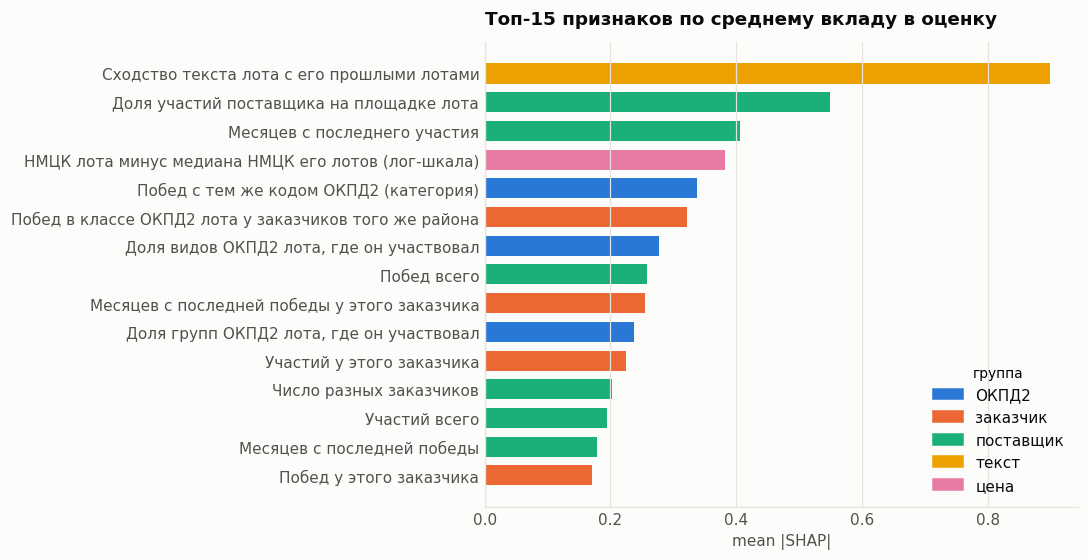

,суммарный вклад
группа,
поставщик,2.033389
ОКПД2,1.093289
заказчик,1.048684
текст,0.898165
цена,0.527555
лот,0.185022


In [12]:
rng = np.random.default_rng(SEED)
sample_lots = rng.choice(test.lot_id.unique(), size=1000, replace=False)
S = test[test.lot_id.isin(sample_lots)].reset_index(drop=True)
t0 = time.time()
contrib = booster.predict(S[FEATURES], num_iteration=BEST, pred_contrib=True)
print(f'SHAP для {fmt(len(S))} пар за {time.time() - t0:.0f} с')
imp = pd.Series(np.abs(contrib[:, :-1]).mean(axis=0), index=FEATURES).sort_values(ascending=False)
imp_df = pd.DataFrame({'признак': imp.index, 'описание': imp.index.map(TITLE), 'группа': imp.index.map(GROUP), 'mean|SHAP|': imp.values})

top = imp.head(15)
fig, ax = plt.subplots(figsize=(10, 5.2))
gcol = {'ОКПД2': C_BLUE, 'заказчик': C_ORANGE, 'поставщик': C_AQUA, 'текст': C_YELLOW, 'цена': '#e87ba4', 'лот': INK2}
labels = [TITLE[f] for f in top.index][::-1]
ax.barh(labels, top.values[::-1], color=[gcol[GROUP[f]] for f in top.index][::-1], height=0.7)
handles = [mpl.patches.Patch(color=c, label=g) for g, c in gcol.items() if g in set(GROUP[f] for f in top.index)]
ax.legend(handles=handles, loc='lower right', title='группа', title_fontsize=9)
ax.set_title('Топ-15 признаков по среднему вкладу в оценку'); ax.set_xlabel('mean |SHAP|'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
display(imp_df.groupby('группа')['mean|SHAP|'].sum().sort_values(ascending=False).to_frame('суммарный вклад'))

### 5.2 Как признак влияет на оценку

Зависимость вклада от значения признака для четырёх самых важных признаков. Для монотонных признаков кривая не убывает по построению.

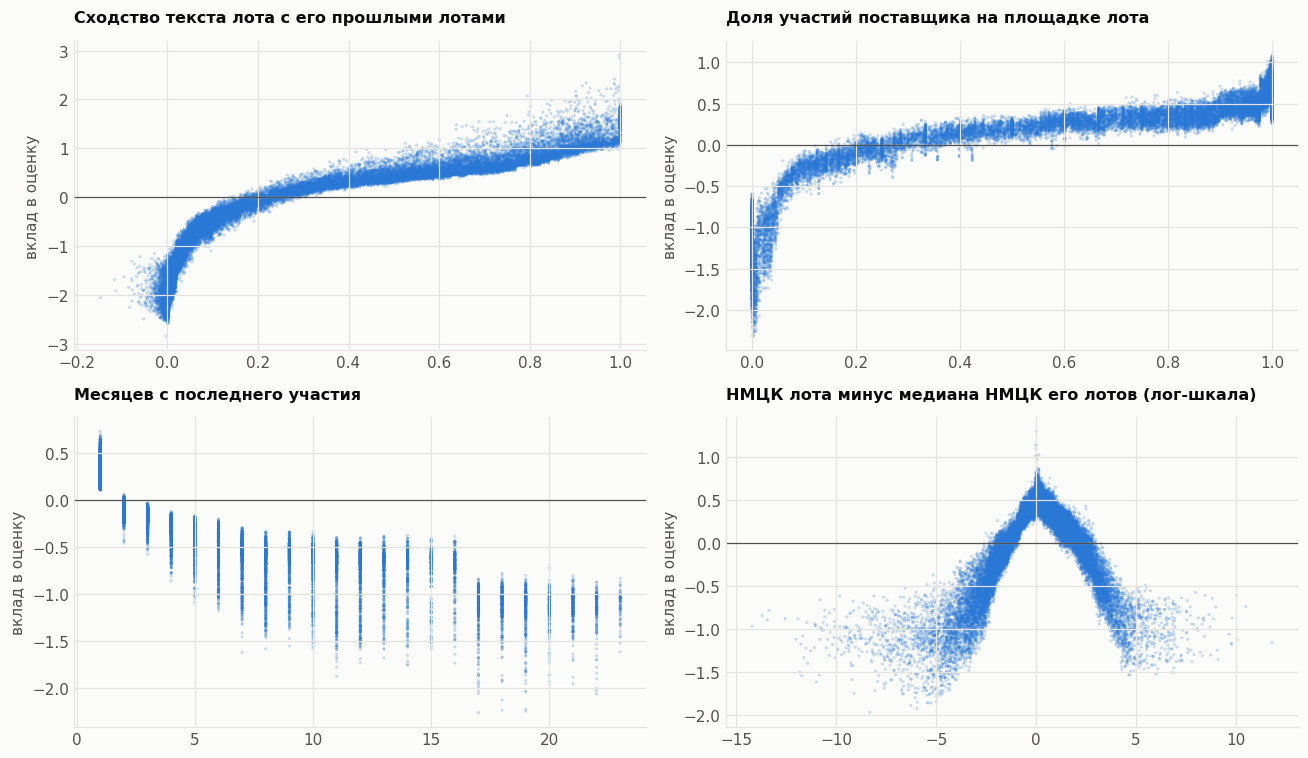

In [13]:
top4 = [f for f in imp.index if GROUP[f] != 'лот'][:4]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sub = rng.choice(len(S), size=min(30000, len(S)), replace=False)
for ax, f in zip(axes.ravel(), top4):
    j = FEATURES.index(f)
    x, y = S[f].values[sub], contrib[sub, j]
    ok = np.isfinite(x)
    if np.nanmax(x) > 50:
        ax.set_xscale('symlog')
    ax.scatter(x[ok], y[ok], s=4, alpha=0.25, color=C_BLUE, edgecolors='none')
    ax.axhline(0, color=INK2, lw=0.8)
    ax.set_title(TITLE[f], fontsize=10.5); ax.set_ylabel('вклад в оценку')
    if (~ok).any():
        ax.annotate(f'нет значения: средний вклад {y[~ok].mean():+.2f}', (0.02, 0.92), xycoords='axes fraction', color=INK2, fontsize=9)
plt.tight_layout(); plt.show()

### 5.3 Калибровка вероятности победы на test

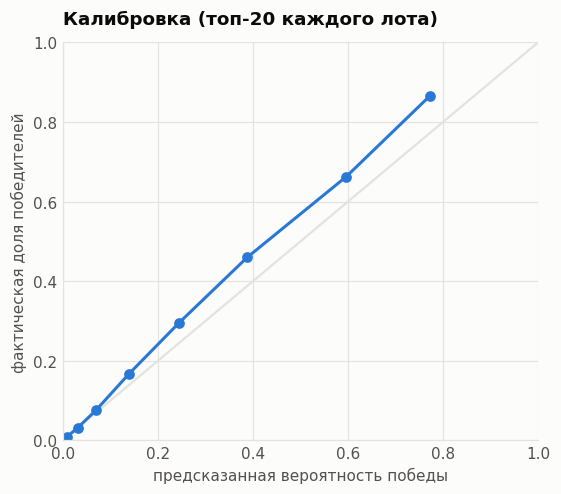

,pred,fact,n
bin,,,
"(0.0, 0.02]",0.8%,0.8%,1220678
"(0.02, 0.05]",3.1%,3.1%,316077
"(0.05, 0.1]",6.9%,7.5%,111219
"(0.1, 0.2]",13.9%,16.7%,56187
"(0.2, 0.3]",24.4%,29.5%,19753
"(0.3, 0.5]",38.9%,46.0%,19039
"(0.5, 0.7]",59.6%,66.2%,11024
"(0.7, 1.0]",77.2%,86.5%,9023


In [14]:
cal = test[['lot_id', 'p_win', 'label']].copy()
cal['is_win'] = (cal.label == 2).astype(int)
top20 = test.sort_values(['lot_id', 'score'], ascending=[True, False]).groupby('lot_id').head(20)
cal = cal.loc[top20.index]
bins = [0, .02, .05, .1, .2, .3, .5, .7, 1]
cal['bin'] = pd.cut(cal.p_win, bins)
rel = cal.groupby('bin', observed=True).agg(pred=('p_win', 'mean'), fact=('is_win', 'mean'), n=('is_win', 'size'))
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], color=GRID, lw=1.5)
ax.plot(rel.pred, rel.fact, color=C_BLUE, marker='o')
ax.set_xlabel('предсказанная вероятность победы'); ax.set_ylabel('фактическая доля победителей')
ax.set_title('Калибровка (топ-20 каждого лота)'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()
display(rel.assign(pred=rel.pred.map(pct), fact=rel.fact.map(pct)))

### 5.4 Примеры выдачи с объяснениями

Для трёх тестовых лотов: топ-10 кандидатов, вероятность победы, статус, причины и риски. Реальный победитель отмечен ★.

In [15]:
raw = pd.read_parquet('data/processed/lots.parquet', columns=['lot_id', 'subject', 'platform', 'start_price', 'customer_inn'])
inn = ds.suppliers.set_index('sid').inn

def show_lot(lot_id, k=10):
    L = raw[raw.lot_id == lot_id].iloc[0]
    sub = test[test.lot_id == lot_id].sort_values('score', ascending=False).head(k).reset_index(drop=True)
    con = booster.predict(sub[FEATURES], num_iteration=BEST, pred_contrib=True)
    ex = explain(sub, con)
    wr = winner_ranks(test[test.lot_id == lot_id], truth[truth.lot_id == lot_id], 'score').iloc[0]
    print(f'Лот {lot_id} · {L.platform} · НМЦК {fmt(L.start_price)} ₽ · заказчик {L.customer_inn}')
    print(f'Предмет: {L.subject[:180]}')
    print(f'Место реального победителя в выдаче модели: {"нет среди кандидатов" if not np.isfinite(wr) else int(wr)}')
    out = pd.DataFrame({
        '#': range(1, len(sub) + 1),
        'ИНН': sub.sid.map(inn).values,
        '': np.where(sub.label == 2, '★', np.where(sub.label == 1, '·', '')),
        'P(победа)': sub.p_win.map(pct).values,
        'статус': ex.status.values,
        'причины': ex.reasons.map(lambda r: ' | '.join(r)).values,
        'риски': ex.risks.map(lambda r: ' | '.join(r)).values,
    })
    display(out)

wr_all = r_model
seg = w.set_index('lot_id').segment
ex1 = wr_all[(wr_all == 1) & (seg.reindex(wr_all.index) == '2. Побеждал в классе, новый для заказчика') & (wr_all.index.map(plat) == 'EM')].sample(1, random_state=1).index[0]
ex2 = wr_all[(wr_all <= 3) & (wr_all.index.map(plat) == 'AISGZ') & (wr_all.index.isin(w[w.n_positions > 5].lot_id))].sample(1, random_state=2).index[0]
ex3 = wr_all[(wr_all > 10) & np.isfinite(wr_all)].sample(1, random_state=3).index[0]
for lid in [ex1, ex2, ex3]:
    show_lot(lid); print()

Лот 5894490 · EM · НМЦК 596 555 ₽ · заказчик 7811775001
Предмет: Поставка продуктов питания (УИС)
Место реального победителя в выдаче модели: 1


,#,ИНН,,P(победа),статус,причины,риски
0,1,7840476380,★,19.8%,Проверенный,25 побед в этом классе ОКПД2 у заказчиков того же района | 127 побед с точно таким же кодом ОКПД2 | Обычно работает на этой площадке (85% участий),Не работал с этим заказчиком
1,2,7811341830,,18.2%,Проверенный,680 побед в этом классе ОКПД2 у заказчиков того же района | Предмет закупки похож на его прошлые контракты (сходство 0.54) | 277 побед с точно таким же кодо...,Низкая доля побед: 100%
2,3,7811040293,·,13.5%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.61) | 8 побед в этом классе ОКПД2 у заказчиков того же района | Работал с этим заказчиком: 7 побе...,Последнее участие 2 месяца назад
3,4,5036169909,,2.6%,Проверенный,Обычно работает на этой площадке (100% участий) | НМЦК близка к его типичным контрактам | 30 побед с точно таким же кодом ОКПД2,Низкая доля побед: 100%
4,5,7810238406,,2.2%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.39) | Обычно работает на этой площадке (72% участий) | НМЦК близка к его типичным контрактам,Не работал с этим заказчиком
5,6,7807386740,,1.0%,Проверенный,НМЦК близка к его типичным контрактам | 15 побед с точно таким же кодом ОКПД2 | Предмет закупки похож на его прошлые контракты (сходство 0.35),Низкая доля побед: 100%
6,7,7807313727,,0.8%,Проверенный,НМЦК близка к его типичным контрактам | 14 побед с точно таким же кодом ОКПД2 | Обычно работает на этой площадке (77% участий),Низкая доля побед: 98%
7,8,7817306535,,0.8%,Проверенный,Обычно работает на этой площадке (95% участий) | Работал с 207 заказчиками | 25 побед с точно таким же кодом ОКПД2,НМЦК выше его типичных контрактов примерно в 20 раз
8,9,7842469029,,0.7%,Проверенный,Обычно работает на этой площадке (100% участий) | НМЦК близка к его типичным контрактам | Предмет закупки похож на его прошлые контракты (сходство 0.40),Последнее участие 2 месяца назад
9,10,7804682765,,0.6%,Проверенный,НМЦК близка к его типичным контрактам | 6 побед с точно таким же кодом ОКПД2 | Обычно работает на этой площадке (40% участий),Последнее участие 3 месяца назад



Лот 5879153 · AISGZ · НМЦК 5 000 000 ₽ · заказчик 7807015216
Предмет: Поставка изделий медицинского назначения
Место реального победителя в выдаче модели: 1


,#,ИНН,,P(победа),статус,причины,риски
0,1,770102238140,★,32.0%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.95) | НМЦК близка к его типичным контрактам | 3 победы в этом классе ОКПД2 у заказчиков того же р...,Последнее участие 11 месяцев назад
1,2,7816584226,,24.3%,Активный участник,"Предмет закупки похож на его прошлые контракты (сходство 0.78) | Работал с этим заказчиком: 22 победы, 23 участия | Последний раз выигрывал у этого заказчик...",НМЦК вне его обычного ценового диапазона
2,3,7811716870,,4.7%,Активный участник,Предмет закупки похож на его прошлые контракты (сходство 0.63) | Последний раз выигрывал у этого заказчика 3 месяца назад | Опытный поставщик: 2 победы всего,Редко работает на этой площадке (0% участий)
3,4,7810741962,,3.5%,Активный участник,"Предмет закупки похож на его прошлые контракты (сходство 0.48) | Работал с этим заказчиком: 9 побед, 9 участий | 1 победа в этом классе ОКПД2 у заказчиков т...",НМЦК вне его обычного ценового диапазона
4,5,7810768509,,2.8%,Проверенный,Последний раз выигрывал у этого заказчика в текущем месяце | Предмет закупки похож на его прошлые контракты (сходство 0.39) | 8 побед с точно таким же кодом...,НМЦК вне его обычного ценового диапазона
5,6,7736330280,,1.3%,Активный участник,"Предмет закупки похож на его прошлые контракты (сходство 0.51) | Работал с этим заказчиком: 20 побед, 21 участие | Последний раз выигрывал у этого заказчика...",Нет побед с кодами ОКПД2 этого лота
6,7,7801333847,,1.2%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.50) | Последний раз выигрывал у этого заказчика в текущем месяце | Обычно работает на этой площад...,НМЦК вне его обычного ценового диапазона
7,8,780527082270,,0.8%,Новый в категории,Предмет закупки похож на его прошлые контракты (сходство 0.69) | Последний раз выигрывал у этого заказчика 5 месяцев назад | Опытный поставщик: 3 победы всего,Нет побед с кодами ОКПД2 этого лота
8,9,7805808996,,0.6%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.85) | 46 побед с точно таким же кодом ОКПД2 | Обычно работает на этой площадке (70% участий),НМЦК вне его обычного ценового диапазона
9,10,7842513214,,0.6%,Новый в категории,Предмет закупки похож на его прошлые контракты (сходство 0.85) | Последний раз выигрывал у этого заказчика 5 месяцев назад | Обычно работает на этой площадк...,Нет побед с кодами ОКПД2 этого лота



Лот 6015632 · EM · НМЦК 355 218 ₽ · заказчик 7807027726
Предмет: Поставка продуктов питания в ГБДОУ ЦРР детский сад №24 Красносельского района Санкт-Петербурга (январь-февраль 2026) лот 2
Место реального победителя в выдаче модели: 13


,#,ИНН,,P(победа),статус,причины,риски
0,1,7817306535,,42.4%,Проверенный,116 побед в этом классе ОКПД2 у заказчиков того же района | Предмет закупки похож на его прошлые контракты (сходство 0.80) | Обычно работает на этой площадк...,Не работал с этим заказчиком
1,2,7806410527,,11.9%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.85) | 8 побед в этом классе ОКПД2 у заказчиков того же района | Работал с 194 заказчиками,Не работал с этим заказчиком
2,3,7840476380,,7.5%,Проверенный,73 победы в этом классе ОКПД2 у заказчиков того же района | Предмет закупки похож на его прошлые контракты (сходство 0.59) | Обычно работает на этой площадк...,Не работал с этим заказчиком
3,4,7804054351,,4.5%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.83) | Работал с 242 заказчиками | 60 побед с точно таким же кодом ОКПД2,Не работал с этим заказчиком
4,5,4705055285,,1.5%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.87) | НМЦК близка к его типичным контрактам | 20 побед с точно таким же кодом ОКПД2,Не работал с этим заказчиком
5,6,7802862201,,1.4%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.79) | Обычно работает на этой площадке (77% участий) | 15 побед с точно таким же кодом ОКПД2,Не работал с этим заказчиком
6,7,380400643252,,0.9%,Активный участник,Предмет закупки похож на его прошлые контракты (сходство 0.86) | НМЦК близка к его типичным контрактам | Обычно работает на этой площадке (88% участий),Не работал с этим заказчиком
7,8,7804471404,,0.9%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.78) | 92 победы с точно таким же кодом ОКПД2 | Обычно работает на этой площадке (64% участий),Не работал с этим заказчиком
8,9,7817080623,,0.7%,Проверенный,Предмет закупки похож на его прошлые контракты (сходство 0.88) | 12 побед с точно таким же кодом ОКПД2 | НМЦК близка к его типичным контрактам,Не работал с этим заказчиком
9,10,7807399379,,0.6%,Активный участник,Предмет закупки похож на его прошлые контракты (сходство 0.80) | НМЦК близка к его типичным контрактам | Обычно работает на этой площадке (72% участий),Нет побед с кодами ОКПД2 этого лота


## 6. Разбор ошибок

In [16]:
w['исход'] = pd.cut(w.r_model, [0, 1, 10, 50, 300, np.inf], labels=['топ-1', '2–10', '11–50', '51–300', 'нет в кандидатах'])
display(pd.crosstab(w.segment, w['исход'], normalize='index').map(pct))
miss = w[~np.isfinite(w.r_model)]
print(f'Промахи генератора: {fmt(len(miss))} лотов ({pct(len(miss) / len(w))})')
display(miss.segment.value_counts(normalize=True).map(pct).to_frame('доля промахов'))

# Победитель среди кандидатов, но ниже топ-10: чем он отличается от того, кто стоит первым
far = w[(w.r_model > 10) & np.isfinite(w.r_model)].lot_id
cmp_cols = ['cust_win', 'cust_class_win', 'code_win_l5', 'code_win_l3', 'text_cos', 's_n_win', 's_m_since_win', 'price_in_range']
first = test[test.lot_id.isin(far)].sort_values(['lot_id', 'score'], ascending=[True, False]).groupby('lot_id').head(1)
winners = test[test.lot_id.isin(far) & (test.label == 2)]
pd.DataFrame({'Первый в выдаче (медиана)': first[cmp_cols].median(), 'Реальный победитель (медиана)': winners[cmp_cols].median()}).rename(index=TITLE).round(2)

исход,топ-1,2–10,11–50,51–300,нет в кандидатах
segment,,,,,
1. Побеждал у этого заказчика,54.6%,30.7%,9.9%,3.2%,1.6%
"2. Побеждал в классе, новый для заказчика",12.2%,39.7%,24.2%,9.0%,14.9%
"3. Участвовал, но не побеждал в классе",0.4%,4.0%,9.8%,9.7%,76.2%
4. Нет истории до лота,0.0%,0.0%,0.0%,0.0%,100.0%


Промахи генератора: 10 182 лотов (11.6%)


,доля промахов
segment,
"2. Побеждал в классе, новый для заказчика",40.5%
4. Нет истории до лота,31.8%
"3. Участвовал, но не побеждал в классе",19.2%
1. Побеждал у этого заказчика,8.6%


,Первый в выдаче (медиана),Реальный победитель (медиана)
Побед у этого заказчика,1.00,0.00
Побед у этого заказчика в классе ОКПД2 лота,1.00,0.00
Побед с тем же видом ОКПД2,21.00,4.00
Побед с той же группой ОКПД2,45.00,10.00
Сходство текста лота с его прошлыми лотами,0.64,0.44
Побед всего,157.00,62.00
Месяцев с последней победы,1.00,1.00
НМЦК в его диапазоне p10–p90,1.00,1.00


## 7. Артефакты для прода

- `ranker.txt` — модель LightGBM (лучшая итерация);
- `meta.json` — признаки, монотонность, параметры, температура, метрики, пороги НМЦК;
- `text_model.joblib`, `vocab.npz`, `suppliers.parquet`;
- `snapshot/` — профили поставщиков на всю историю (срез 2026-01) для сервиса.

In [17]:
lots_raw = pd.read_parquet('data/processed/lots.parquet', columns=['platform', 'start_price'])
price_cap = lots_raw.groupby('platform').start_price.quantile(0.999).to_dict()
test_metrics = {f'{a}|{b}': {k: round(v, 4) for k, v in res.loc[(a, b)].items()} for a, b in res.index}

booster.save_model(str(MODEL_DIR / 'ranker.txt'), num_iteration=BEST)
meta = {
    'features': FEATURES, 'titles': TITLE, 'groups': GROUP, 'monotone': MONOTONE,
    'params': {k: v for k, v in PARAMS.items() if k != 'monotone_constraints'},
    'best_iteration': BEST, 'temperature': TEMP, 'candidate_coverage': COVERAGE,
    'price_cap': {'EM': float(price_cap['EM']), 'AISGZ': float(price_cap['AISGZ'])},
    'train_months': [month_label(m) for m in TRAIN_MONTHS], 'valid_month': month_label(VALID_MONTH),
    'test_months': [month_label(m) for m in TEST_MONTHS], 'test_metrics': test_metrics,
    'candidates': {'n_code': C.N_CODE, 'n_cust': C.N_CUST, 'n_text': C.N_TEXT, 'keep': C.KEEP},
}
(MODEL_DIR / 'meta.json').write_text(json.dumps(meta, ensure_ascii=False, indent=1), encoding='utf-8')
ds.vocab.save(MODEL_DIR / 'vocab.npz')
ds.suppliers.to_parquet(MODEL_DIR / 'suppliers.parquet')
t0 = time.time()
prod_snap = Snapshot.build(ds, int(ds.lots.month.max()) + 1, lot_vecs)
prod_snap.save(MODEL_DIR / 'snapshot')
print(f'Срез для прода: cutoff {month_label(prod_snap.cutoff)}, активных поставщиков {fmt(len(prod_snap.active))}, {time.time() - t0:.0f} с')
pd.DataFrame([{'файл': p.name, 'МБ': round(sum(f.stat().st_size for f in ([p] if p.is_file() else p.rglob('*'))) / 2**20, 1)}
              for p in sorted(MODEL_DIR.iterdir())])

Срез для прода: cutoff 2026-01, активных поставщиков 44 161, 10 с


,файл,МБ
0,meta.json,0.0
1,ranker.txt,3.4
2,snapshot,53.9
3,suppliers.parquet,0.7
4,text_model.joblib,205.7
5,vocab.npz,0.3


### Проверка сервисного инференса

Сервис получает сырой лот (как в извещении + позиции ТРУ) и сам делает очистку текста, коды, кандидатов, признаки и объяснения. Ниже — **пример нового лота**, составленный вручную для демонстрации: реальный заказчик из данных, вымышленный предмет закупки.

In [18]:
from recsys.inference import Recommender
rec = Recommender(MODEL_DIR)
cust = raw[raw.platform == 'EM'].customer_inn.value_counts().index[0]
example_lot = {
    'subject': 'Поставка крупы гречневой и риса для нужд ГБДОУ детский сад № 10 в 2026 году',
    'items': [{'name': 'Крупа гречневая ядрица', 'okpd2': '10.61.32.113'},
              {'name': 'Рис шлифованный', 'okpd2': '10.61.11.000'}],
    'start_price': 180000, 'is_smp': False, 'platform': 'EM', 'customer_inn': cust,
    'customer_kpp': ds.lots.loc[ds.lots.customer_inn == cust, 'customer_district'].iloc[0] + '01001',
}
t0 = time.time()
out = rec.recommend(example_lot, top_n=10)
print(f'Ответ за {time.time() - t0:.1f} с; заказчик {cust}')
out.assign(p_win=out.p_win.map(pct), reasons=out.reasons.map(' | '.join), risks=out.risks.map(' | '.join)).drop(columns=['score', 'status_rule'])

Ответ за 1.8 с; заказчик 7808046224


,rank,inn,p_win,reasons,risks,status
0,1,7804054351,62.2%,Предмет закупки похож на его прошлые контракты (сходство 0.75) | Последний раз выигрывал у этого заказчика в текущем месяце | Работал с этим заказчиком: 7 п...,,Проверенный
1,2,7817306535,2.4%,Предмет закупки похож на его прошлые контракты (сходство 0.56) | Обычно работает на этой площадке (75% участий) | Работал с 250 заказчиками,Не работал с этим заказчиком,Проверенный
2,3,7806410527,1.9%,Предмет закупки похож на его прошлые контракты (сходство 0.68) | 35 побед с точно таким же кодом ОКПД2 | Работал с 199 заказчиками,Не работал с этим заказчиком,Проверенный
3,4,7807399379,1.6%,Предмет закупки похож на его прошлые контракты (сходство 0.69) | НМЦК близка к его типичным контрактам | Обычно работает на этой площадке (68% участий),Нет побед с кодами ОКПД2 этого лота,Активный участник
4,5,7802862201,1.1%,Предмет закупки похож на его прошлые контракты (сходство 0.73) | Обычно работает на этой площадке (77% участий) | 9 побед с точно таким же кодом ОКПД2,Не работал с этим заказчиком,Проверенный
5,6,7840476380,1.0%,Обычно работает на этой площадке (88% участий) | Работал с 248 заказчиками | Предмет закупки похож на его прошлые контракты (сходство 0.36),Не работал с этим заказчиком,Проверенный
6,7,7807313727,0.9%,Предмет закупки похож на его прошлые контракты (сходство 0.65) | Обычно работает на этой площадке (93% участий) | Работал с 177 заказчиками,Не работал с этим заказчиком,Проверенный
7,8,7804471404,0.9%,Предмет закупки похож на его прошлые контракты (сходство 0.81) | 8 побед с точно таким же кодом ОКПД2 | Обычно работает на этой площадке (64% участий),Не работал с этим заказчиком,Проверенный
8,9,4704111755,0.8%,Предмет закупки похож на его прошлые контракты (сходство 0.68) | 7 побед в этом классе ОКПД2 у заказчиков того же района | Обычно работает на этой площадке ...,Не работал с этим заказчиком,Проверенный
9,10,380400643252,0.5%,НМЦК близка к его типичным контрактам | Предмет закупки похож на его прошлые контракты (сходство 0.55) | Обычно работает на этой площадке (88% участий),Последнее участие 3 месяца назад,Активный участник


## 8. Итоги

_Заполняется по результатам выполнения._